# [Notebook 06] Modelagem de Fluxo de Tráfego em Redes Urbanas

> **Série:** Sistemas Lineares: teoria, interpretação geométrica e aplicações com Python  
> **Pré-requisito:** `05_transformacoes_lineares_sistemas.ipynb`  
> **Próximo:** Tópicos Avançados (em breve)

---

## Objetivo
Aplicar os conceitos de sistemas lineares para modelar e resolver problemas de fluxo de tráfego em redes viárias urbanas.

---

## 1. O Problema da Rede Viária

Imagine uma pequena seção de uma rede urbana com 4 cruzamentos (A, B, C e D) conectados por ruas de mão única. O fluxo de veículos que entra na rede deve ser igual ao fluxo que sai dela (Lei de Conservação de Fluxo).

### Desenho da Rede (Esquema)
Representaremos a rede com os seguintes fluxos (veículos por hora - vph):

*   **Entradas:**
    *   No cruzamento A: 500 vph
    *   No cruzamento B: 300 vph
*   **Saídas:**
    *   No cruzamento C: 400 vph
    *   No cruzamento D: 400 vph
*   **Variáveis internas (fluxos entre cruzamentos):**
    *   $x_1$: de A para B
    *   $x_2$: de B para C
    *   $x_3$: de C para D
    *   $x_4$: de D para A
    *   $x_5$: de A para C (atalho)

---

## 2. Hipóteses e Variáveis do Modelo

### Hipóteses:
1.  **Conservação de Fluxo:** Em cada cruzamento, o fluxo total de entrada é igual ao fluxo total de saída.
2.  **Mão Única:** As direções dos fluxos são fixas conforme o esquema.
3.  **Estado Estacionário:** Os fluxos são constantes no tempo considerado.

### Variáveis:
*   $x_1, x_2, x_3, x_4, x_5$: Fluxos nas ruas internas (incógnitas).

---

## 3. Montando o Sistema Linear

Para cada cruzamento, escrevemos a equação de balanço: **Entrada = Saída**.

*   **Cruzamento A:** $500 + x_4 = x_1 + x_5$  $\implies x_1 - x_4 + x_5 = 500$
*   **Cruzamento B:** $300 + x_1 = x_2$ $\implies x_1 - x_2 = -300$
*   **Cruzamento C:** $x_2 + x_5 = x_3 + 400$ $\implies x_2 - x_3 + x_5 = 400$
*   **Cruzamento D:** $x_3 = x_4 + 400$ $\implies x_3 - x_4 = 400$

Note que o fluxo total de entrada ($500+300=800$) é igual ao de saída ($400+400=800$).

---

## 4. Forma Matricial $Ax = b$

O sistema acima pode ser escrito como:

$$
\begin{pmatrix}
1 & 0 & 0 & -1 & 1 \\
1 & -1 & 0 & 0 & 0 \\
0 & 1 & -1 & 0 & 1 \\
0 & 0 & 1 & -1 & 0
\end{pmatrix}
\begin{pmatrix}
x_1 \\ x_2 \\ x_3 \\ x_4 \\ x_5
\end{pmatrix}
=
\begin{pmatrix}
500 \\ -300 \\ 400 \\ 400
\end{pmatrix}
$$

Este é um sistema com 4 equações e 5 incógnitas, o que sugere que teremos pelo menos uma variável livre (SPI).

---

## 5. Resolução com SymPy

Vamos encontrar a solução geral desse sistema.


In [1]:
import sympy as sp

# Definindo as variáveis
x1, x2, x3, x4, x5 = sp.symbols('x1 x2 x3 x4 x5')

# Matriz A e vetor b
A = sp.Matrix([
    [1,  0,  0, -1,  1],
    [1, -1,  0,  0,  0],
    [0,  1, -1,  0,  1],
    [0,  0,  1, -1,  0]
])

b = sp.Matrix([500, -300, 400, 400])

# Matriz aumentada
aug = A.row_join(b)

# Forma Escalonada Reduzida (RREF)
rref_matrix, pivot_indices = aug.rref()

print("Matriz Aumentada na forma RREF:")
sp.pprint(rref_matrix)

# Solução Geral
sol = sp.solve_linear_system(aug, x1, x2, x3, x4, x5)
print("\nSolução Geral:")
print(sol)

Matriz Aumentada na forma RREF:
⎡1  0  0  -1  1  500⎤
⎢                   ⎥
⎢0  1  0  -1  1  800⎥
⎢                   ⎥
⎢0  0  1  -1  0  400⎥
⎢                   ⎥
⎣0  0  0  0   0   0 ⎦

Solução Geral:
{x1: x4 - x5 + 500, x2: x4 - x5 + 800, x3: x4 + 400}


---

## 6. Visualização da Rede e Fluxos

Para visualizar a rede, usaremos o `networkx`.


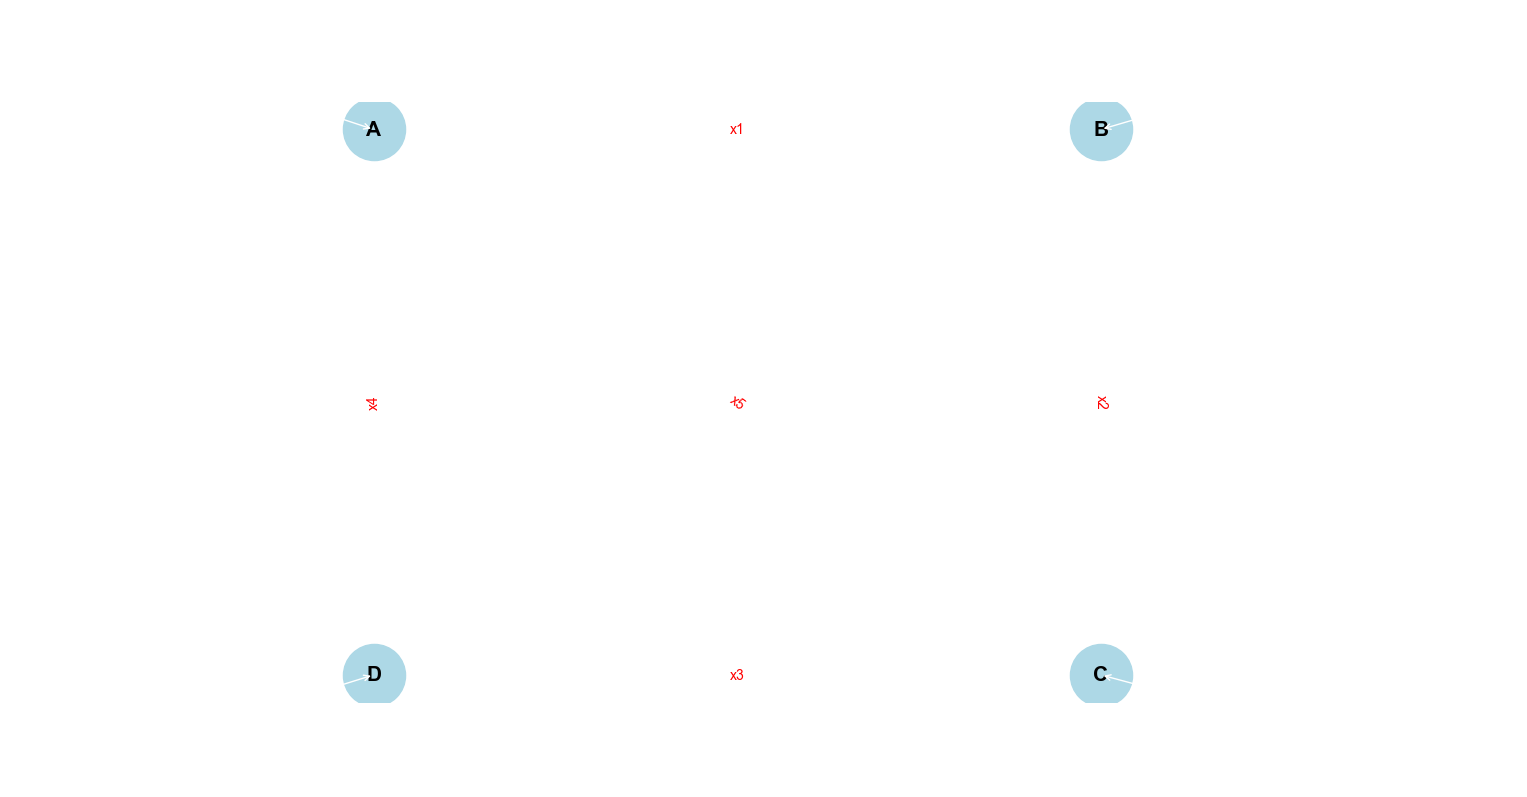

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_traffic_network(flow_values=None):
    G = nx.DiGraph()
    
    # Adicionando nós (Cruzamentos)
    nodes = ['A', 'B', 'C', 'D']
    G.add_nodes_from(nodes)
    
    # Adicionando arestas internas com nomes das variáveis
    edges = [
        ('A', 'B', 'x1'),
        ('B', 'C', 'x2'),
        ('C', 'D', 'x3'),
        ('D', 'A', 'x4'),
        ('A', 'C', 'x5')
    ]
    
    pos = {'A': (0, 1), 'B': (1, 1), 'C': (1, 0), 'D': (0, 0)}
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', 
            font_size=15, font_weight='bold', arrows=True, connectionstyle='arc3, rad = 0.1')
    
    # Labels das arestas
    edge_labels = {(u, v): label for u, v, label in edges}
    
    if flow_values:
        # Se valores de fluxo forem passados, mostramos o valor
        edge_labels = {(u, v): f"{label}={flow_values[label]}" for u, v, label in edges}

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    
    # Representando entradas e saídas como setas externas
    plt.annotate('In: 500', xy=(0, 1), xytext=(-0.5, 1.2), arrowprops=dict(arrowstyle="->"))
    plt.annotate('In: 300', xy=(1, 1), xytext=(1.5, 1.2), arrowprops=dict(arrowstyle="->"))
    plt.annotate('Out: 400', xy=(1, 0), xytext=(1.5, -0.2), arrowprops=dict(arrowstyle="->"))
    plt.annotate('Out: 400', xy=(0, 0), xytext=(-0.5, -0.2), arrowprops=dict(arrowstyle="->"))
    
    plt.title("Rede de Tráfego Urbano")
    plt.axis('off')
    plt.show()

plot_traffic_network()

---

## 7. Discussão e Sensibilidade

Como o sistema é **SPI (Indeterminado)**, temos infinitas soluções dependendo do fluxo no "atalho" $x_5$. 

A partir da RREF, podemos expressar as outras variáveis em função de $x_5$ e $x_4$. No entanto, note que na nossa RREF obtivemos:
* $x_1 = x_4 - x_5 + 500$
* $x_2 = x_4 - x_5 + 800$
* $x_3 = x_4 + 400$

Como o fluxo não pode ser negativo ($x_i \ge 0$), isso impõe restrições aos valores possíveis.

### Exemplo de Solução Particular
Se decidirmos fechar o atalho ($x_5 = 0$) e minimizarmos o fluxo circular definindo $x_4 = 0$:


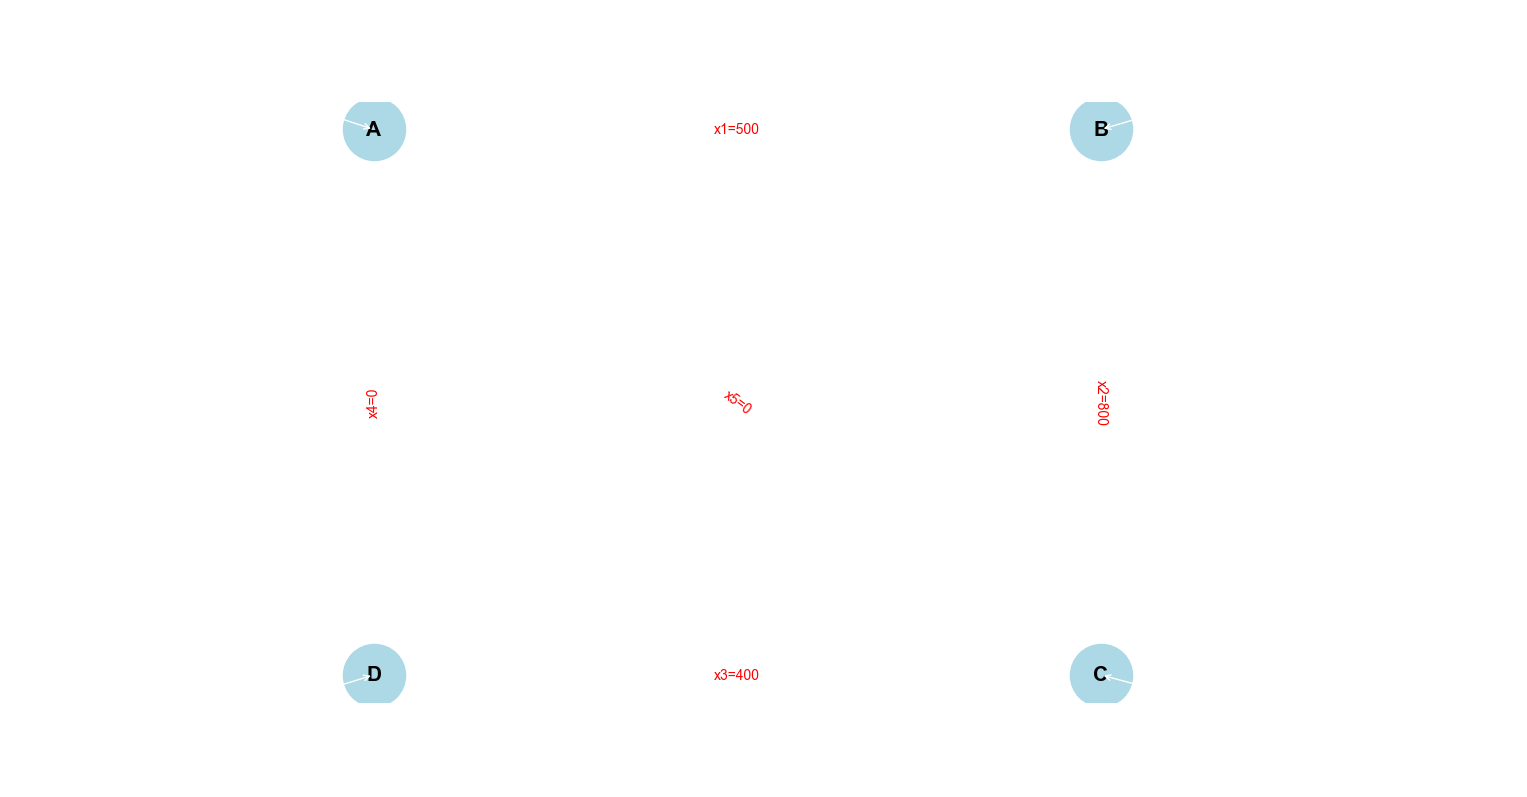

In [3]:
# Definindo x4 = 0 e x5 = 0 na solução geral
particular_sol = {
    'x1': 500,
    'x2': 800,
    'x3': 400,
    'x4': 0,
    'x5': 0
}

plot_traffic_network(particular_sol)

### Sensibilidade
Se o fluxo $x_5$ aumentar, os fluxos $x_1$ e $x_2$ diminuem na mesma proporção, o que faz sentido, já que $x_5$ retira veículos que passariam por A->B e B->C para irem direto para C.

---

## 8. Conclusão

A modelagem de redes viárias com sistemas lineares permite:
*   Prever o impacto de obras (ex: fechamento de uma rua $x_i = 0$).
*   Identificar gargalos (onde o fluxo é maior).
*   Planejar rotas alternativas para equilibrar a carga na rede.

Embora redes reais sejam muito maiores e envolvam dinâmicas não lineares, a base da conservação de fluxo e o uso de matrizes permanecem como ferramentas fundamentais na engenharia de tráfego.
